In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 41.0M/41.0M [00:47<00:00, 906kB/s]

Extracting files...


Path to dataset files: C:\Users\Anshika\.cache\kagglehub\datasets\clmentbisaillon\fake-and-real-news-dataset\versions\1


Fake news shape: (23481, 4)
True news shape: (21417, 4)
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  


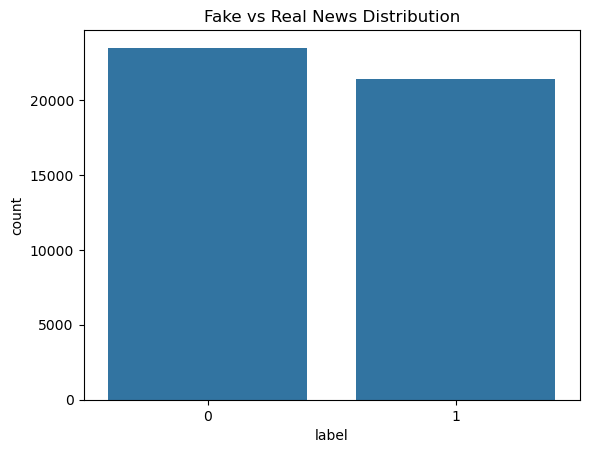

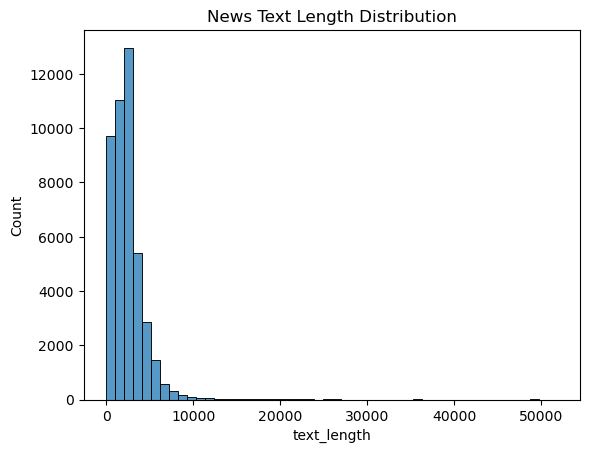

Accuracy: 0.9844097995545658

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4733
           1       0.98      0.98      0.98      4247

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



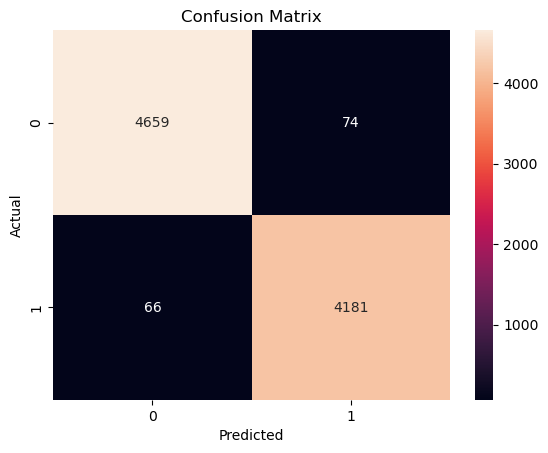

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# 1 Load Dataset
# -----------------------------

fake = pd.read_csv(r"C:\Users\Anshika\.cache\kagglehub\datasets\clmentbisaillon\fake-and-real-news-dataset\versions\1\Fake.csv")
true = pd.read_csv(r"C:\Users\Anshika\.cache\kagglehub\datasets\clmentbisaillon\fake-and-real-news-dataset\versions\1\True.csv")

print("Fake news shape:", fake.shape)
print("True news shape:", true.shape)

# -----------------------------
# 2 Label the Data
# -----------------------------

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true])

print(df.head())

# -----------------------------
# 3 Data Visualization
# -----------------------------

plt.figure()
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.show()

# text length
df["text_length"] = df["text"].apply(len)

plt.figure()
sns.histplot(df["text_length"], bins=50)
plt.title("News Text Length Distribution")
plt.show()

# -----------------------------
# 4 Text Cleaning
# -----------------------------

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

df["text"] = df["text"].apply(clean_text)

# -----------------------------
# 5 Feature Extraction (TF-IDF)
# -----------------------------

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X = vectorizer.fit_transform(df["text"])
y = df["label"]

# -----------------------------
# 6 Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7 Train Model
# -----------------------------

model = LogisticRegression()

model.fit(X_train, y_train)

# -----------------------------
# 8 Prediction
# -----------------------------

pred = model.predict(X_test)

# -----------------------------
# 9 Evaluation
# -----------------------------

print("Accuracy:", accuracy_score(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# 10 Confusion Matrix Graph
# -----------------------------

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()